# Data Analysis with Python

Estimated time needed: **30** minutes

## Objectives

After completing this lab you will be able to:

*   Explore features or charecteristics to predict price of car


> **Phiên bản bài tập / Student version:** notebook này **không kèm đáp án**.  
> Điền code vào các ô `# Write your code below...` và viết nhận xét vào các ô `# Write your conclusion`.


<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#import_data">Import Data from Module</a></li>
    <li><a href="#pattern_visualization">Analyzing Individual Feature Patterns using Visualization</a></li>
    <li><a href="#discriptive_statistics">Descriptive Statistical Analysis</a></li>
    <li><a href="#basic_grouping">Basics of Grouping</a></li>
    <li><a href="#correlation_causation">Correlation and Causation</a></li>
    <li><a href="#anova">ANOVA</a></li>
</ol>

</div>

<hr>


<h3>What are the main characteristics that have the most impact on the car price?</h3>


<h2 id="import_data">1. Import Data from Module 2</h2>


<h4>Setup</h4>


Import libraries:


In [1]:
import pandas as pd
import numpy as np

Load the data and store it in dataframe `df`:


In [2]:
filename="automobileEDA.csv"

In [3]:

df = pd.read_csv(filename)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<h2 id="pattern_visualization">2. Analyzing Individual Feature Patterns Using Visualization</h2>


To install Seaborn we use pip, the Python package manager.


Import visualization packages "Matplotlib" and "Seaborn". Don't forget about "%matplotlib inline" to plot in a Jupyter notebook.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

<h4>How to choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable you are dealing with. This will help us find the right visualization method for that variable.</p>


In [6]:
# list the data types for each column
print(df.dtypes)

symboling              int64
normalized-losses      int64
make                     str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned        str
diesel                 int64
gas                    int64
dtype: object


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #1:</h3>

<b>What is the data type of the column "peak-rpm"? </b>

</div>


In [10]:
# Write your code below and press Shift+Enter to execute
print(df['peak-rpm'].dtypes)

float64


For example, we can calculate the correlation between variables  of type "int64" or "float64" using the method "corr":


In [14]:
print(df['peak-rpm'].corr(df['price']))

-0.10161587407588138


In [ ]:
Tuong quan am yeu giua peak-rpm va price, vi he so tuong quan <0.1

The diagonal elements are always one; we will study correlation more precisely Pearson correlation in-depth at the end of the notebook.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3> Question  #2: </h3>

<p>Find the correlation between the following columns: bore, stroke, compression-ratio, and horsepower.</p>
<p>Hint: if you would like to select those columns, use the following syntax: df[['bore','stroke','compression-ratio','horsepower']]</p>
</div>


In [15]:
# Write your code below and press Shift+Enter to execute
df[['bore','stroke','compression-ratio','horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187923,0.098462
compression-ratio,0.001263,0.187923,1.000000,-0.214514
horsepower,0.566936,0.098462,-0.214514,1.000000


<h2>Continuous Numerical Variables:</h2> 

<p>Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots with fitted lines.</p>

<p>In order to start understanding the (linear) relationship between an individual variable and the price, we can use "regplot" which plots the scatterplot plus the fitted regression line for the data.</p>


Let's see several examples of different linear relationships:


<h3>Positive Linear Relationship</h4>


Let's find the scatterplot of "engine-size" and "price".


(0.0, 53335.21968277524)

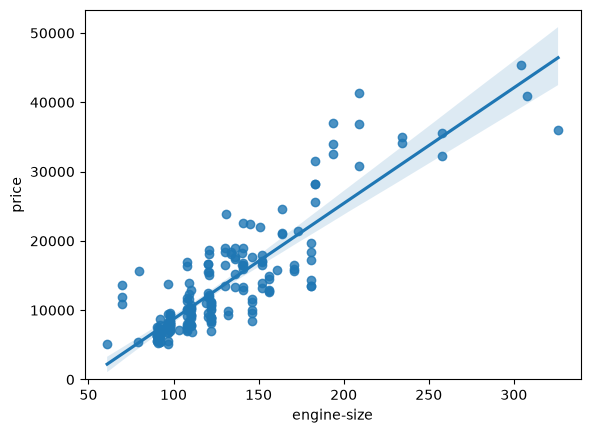

In [16]:
# Engine size as potential predictor variable of price
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)

Có mối tương quan dương khá mạnh giữa kích thước động cơ (engine-size) và giá xe (price). Khi kích thước động cơ tăng, giá xe nhìn chung cũng tăng.

<p>As the engine-size goes up, the price goes up: this indicates a positive direct correlation between these two variables. Engine size seems like a pretty good predictor of price since the regression line is almost a perfect diagonal line.</p>


We can examine the correlation between 'engine-size' and 'price' and see that it's approximately 0.87.


In [17]:
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


Highway mpg is a potential predictor variable of price. Let's find the scatterplot of "highway-mpg" and "price".


In [ ]:
sns.regplot(x="highway-mpg", y="price", data=df)

<p>As highway-mpg goes up, the price goes down: this indicates an inverse/negative relationship between these two variables. Highway mpg could potentially be a predictor of price.</p>


We can examine the correlation between 'highway-mpg' and 'price' and see it's approximately -0.704.


In [18]:
df[['highway-mpg', 'price']].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


<h3>Weak Linear Relationship</h3>


Let's see if "peak-rpm" is a predictor variable of "price".


<Axes: xlabel='peak-rpm', ylabel='price'>

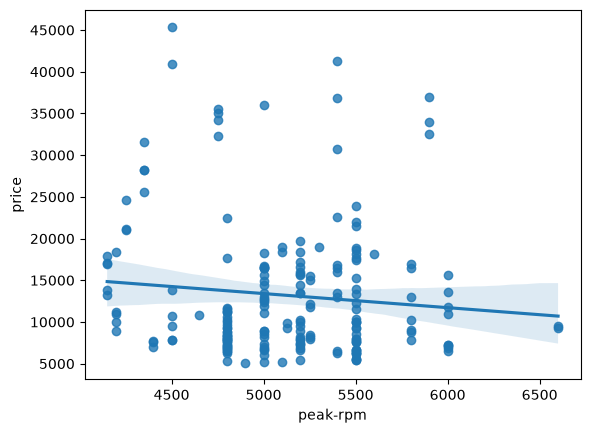

In [19]:
sns.regplot(x="peak-rpm", y="price", data=df)

Biểu đồ cho thấy peak-rpm và price có mối tương quan âm rất yếu. Khi peak-rpm tăng, price có xu hướng giảm nhẹ, nhưng các điểm dữ liệu phân tán rộng nên mối quan hệ giữa hai biến không rõ ràng.

<p>Peak rpm does not seem like a good predictor of the price at all since the regression line is close to horizontal. Also, the data points are very scattered and far from the fitted line, showing lots of variability. Therefore, it's not a reliable variable.</p>


We can examine the correlation between 'peak-rpm' and 'price' and see it's approximately -0.101616.


In [20]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


 <div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  3 a): </h1>

<p>Find the correlation  between x="stroke" and y="price".</p>
<p>Hint: if you would like to select those columns, use the following syntax: df[["stroke","price"]].  </p>
</div>


In [21]:
# Write your code below and press Shift+Enter to execute
df[["stroke","price"]].corr()

,stroke,price
stroke,1.00000,0.08231
price,0.08231,1.00000


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question  3 b):</h1>

<p>Given the correlation results between "price" and "stroke", do you expect a linear relationship?</p> 
<p>Verify your results using the function "regplot()".</p>
</div>


<Axes: xlabel='stroke', ylabel='price'>

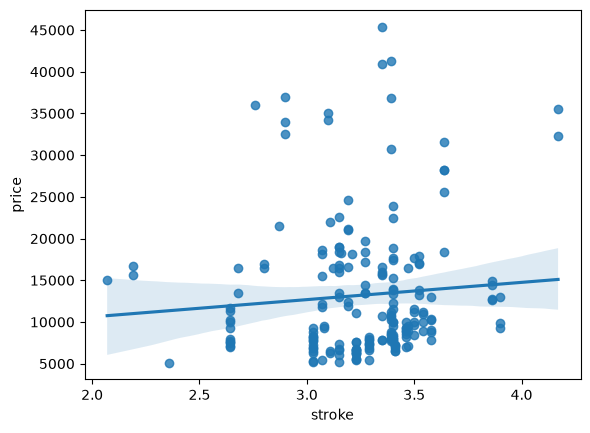

In [24]:
# Write your code below and press Shift+Enter to execute
sns.regplot(x='stroke', y='price', data=df)

Mối quan hệ tương quan dương yếu giữa stroke và price.

<h3>Categorical Variables</h3>

<p>These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.</p>


Let's look at the relationship between "body-style" and "price".


<Axes: xlabel='body-style', ylabel='price'>

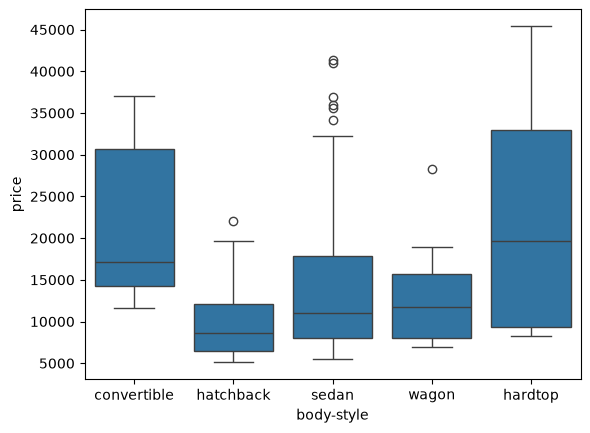

In [25]:
sns.boxplot(x="body-style", y="price", data=df)

<p>We see that the distributions of price between the different body-style categories have a significant overlap, so body-style would not be a good predictor of price. Let's examine engine "engine-location" and "price":</p>


<Axes: xlabel='engine-location', ylabel='price'>

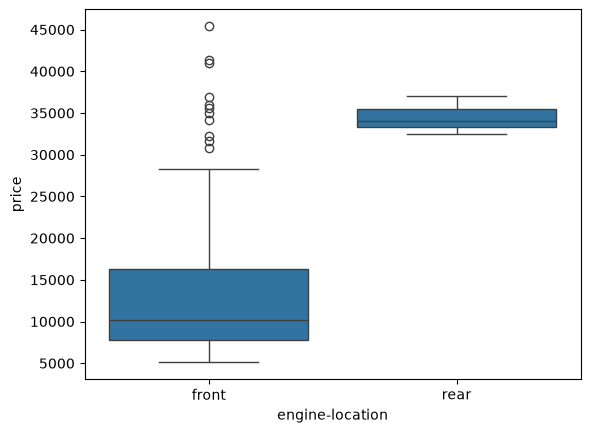

In [26]:
sns.boxplot(x="engine-location", y="price", data=df)

<p>Here we see that the distribution of price between these two engine-location categories, front and rear, are distinct enough to take engine-location as a potential good predictor of price.</p>


Let's examine "drive-wheels" and "price".


<Axes: xlabel='drive-wheels', ylabel='price'>

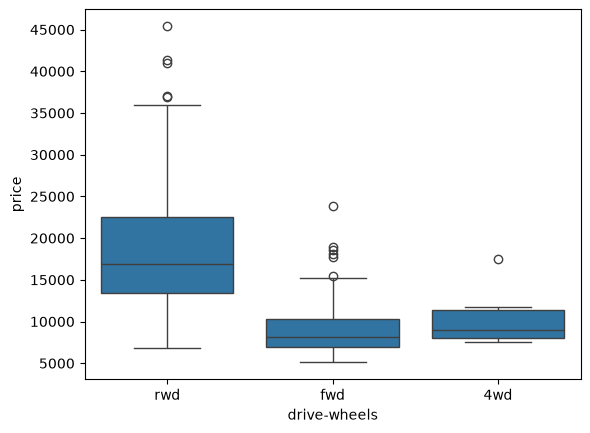

In [27]:
# drive-wheels
sns.boxplot(x="drive-wheels", y="price", data=df)

<p>Here we see that the distribution of price between the different drive-wheels categories differs. As such, drive-wheels could potentially be a predictor of price.</p>


<h2 id="discriptive_statistics">3. Descriptive Statistical Analysis</h2>


<p>Let's first take a look at the variables by utilizing a description method.</p>

<p>The <b>describe</b> function automatically computes basic statistics for all continuous variables. Any NaN values are automatically skipped in these statistics.</p>

This will show:

<ul>
    <li>the count of that variable</li>
    <li>the mean</li>
    <li>the standard deviation (std)</li> 
    <li>the minimum value</li>
    <li>the IQR (Interquartile Range: 25%, 50% and 75%)</li>
    <li>the maximum value</li>
<ul>


We can apply the method "describe" as follows:


In [7]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


The default setting of "describe" skips variables of type object. We can apply the method "describe" on the variables of type 'object' as follows:


In [8]:
df.describe(include='object')

C:\Users\Phuc An\AppData\Local\Temp\ipykernel_16080\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


<h3>Value Counts</h3>


<p>Value counts is a good way of understanding how many units of each characteristic/variable we have. We can apply the "value_counts" method on the column "drive-wheels". Don’t forget the method "value_counts" only works on pandas series, not pandas dataframes. As a result, we only include one bracket <code>df['drive-wheels']</code>, not two brackets <code>df[['drive-wheels']]</code>.</p>


In [10]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

We can convert the series to a dataframe as follows:


In [11]:
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


Let's repeat the above steps but save the results to the dataframe "drive_wheels_counts" and rename the column  'drive-wheels' to 'value_counts'.


In [11]:
drive_wheels_count=df['drive-wheels'].value_counts().to_frame()
drive_wheels_count.rename(columns={'count':'value_counts'}, inplace=True)
drive_wheels_count

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


Now let's rename the index to 'drive-wheels':


In [15]:
drive_wheels_count.index.name
drive_wheels_count

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


We can repeat the above process for the variable 'engine-location'.


In [16]:
engine_loc_counts=df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location':'value_counts'}, inplace=True)
engine_loc_counts.index.name='engine-location'
engine_loc_counts.head(10)

,count
engine-location,
front,198
rear,3


<p>After examining the value counts of the engine location, we see that engine location would not be a good predictor variable for the price. This is because we only have three cars with a rear engine and 198 with an engine in the front, so this result is skewed. Thus, we are not able to draw any conclusions about the engine location.</p>


<h2 id="basic_grouping">4. Basics of Grouping</h2>


<p>The "groupby" method groups data by different categories. The data is grouped based on one or several variables, and analysis is performed on the individual groups.</p>

<p>For example, let's group by the variable "drive-wheels". We see that there are 3 different categories of drive wheels.</p>


In [17]:
df['drive-wheels'].unique()

<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

<p>If we want to know, on average, which type of drive wheel is most valuable, we can group "drive-wheels" and then average them.</p>

<p>We can select the columns 'drive-wheels', 'body-style' and 'price', then assign it to the variable "df_group_one".</p>


In [18]:
df_group_one=df[['drive-wheels','body-style','price']]

We can then calculate the average price for each of the different categories of data.


In [19]:
df_group_one=df_group_one.groupby(['drive-wheels'], as_index=False)['price'].mean()
df_group_one

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


<p>From our data, it seems rear-wheel drive vehicles are, on average, the most expensive, while 4-wheel and front-wheel are approximately the same in price.</p>

<p>You can also group by multiple variables. For example, let's group by both 'drive-wheels' and 'body-style'. This groups the dataframe by the unique combination of 'drive-wheels' and 'body-style'. We can store the results in the variable 'grouped_test1'.</p>


In [20]:
df_gptest=df[['drive-wheels','body-style','price']]
grouped_test1=df_gptest.groupby(['drive-wheels','body-style'], as_index=False)['price'].mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


<p>This grouped data is much easier to visualize when it is made into a pivot table. A pivot table is like an Excel spreadsheet, with one variable along the column and another along the row. We can convert the dataframe to a pivot table using the method "pivot" to create a pivot table from the groups.</p>

<p>In this case, we will leave the drive-wheels variable as the rows of the table, and pivot body-style to become the columns of the table:</p>


In [21]:
grouped_pivot=grouped_test1.pivot(index='drive-wheels', columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<p>Often, we won't have data for some of the pivot cells. We can fill these missing cells with the value 0, but any other value could potentially be used as well. It should be mentioned that missing data is quite a complex subject and is an entire course on its own.</p>


In [22]:
grouped_pivot=grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 4:</h1>

<p>Use the "groupby" function to find the average "price" of each car based on "body-style".</p>
</div>


In [23]:
# Write your code below and press Shift+Enter to execute
avg_body_style_price=df.groupby('body-style')['price'].mean()
avg_body_style_price

body-style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64

If you did not import "pyplot", let's do it again.


In [24]:
import matplotlib.pyplot as plt
%matplotlib inline 

<h4>Variables: Drive Wheels and Body Style vs. Price</h4>


Let's use a heat map to visualize the relationship between Body Style vs Price.


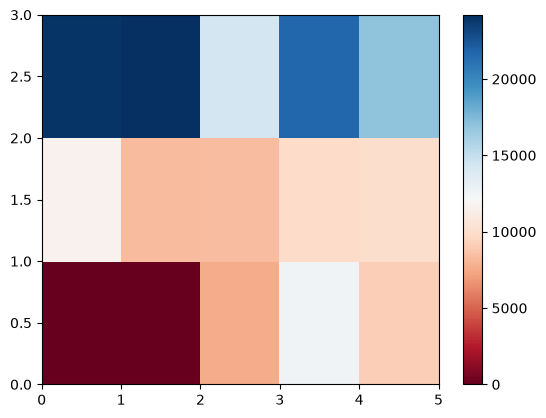

In [25]:
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

<p>The heatmap plots the target variable (price) proportional to colour with respect to the variables 'drive-wheel' and 'body-style' on the vertical and horizontal axis, respectively. This allows us to visualize how the price is related to 'drive-wheel' and 'body-style'.</p>

<p>The default labels convey no useful information to us. Let's change that:</p>


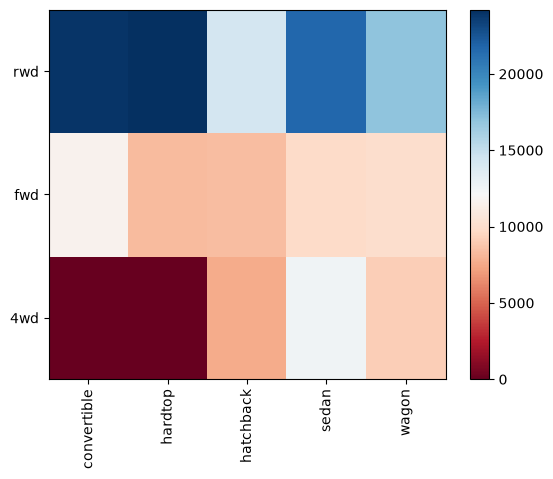

In [26]:
fig, ax =plt.subplots()
im=ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels= grouped_pivot.index

ax.set_xticks(np.arange(grouped_pivot.shape[1])+0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0])+0.5, minor=False)

#them labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

<p>Visualization is very important in data science, and Python visualization packages provide great freedom. We will go more in-depth in a separate Python visualizations course.</p>

<p>The main question we want to answer in this module is, "What are the main characteristics which have the most impact on the car price?".</p>

<p>To get a better measure of the important characteristics, we look at the correlation of these variables with the car price. In other words: how is the car price dependent on this variable?</p>


<h2 id="correlation_causation">5. Correlation and Causation</h2>


<p><b>Correlation</b>: a measure of the extent of interdependence between variables.</p>

<p><b>Causation</b>: the relationship between cause and effect between two variables.</p>

<p>It is important to know the difference between these two. Correlation does not imply causation. Determining correlation is much simpler  the determining causation as causation may require independent experimentation.</p>


<p><b>Pearson Correlation</b></p>
<p>The Pearson Correlation measures the linear dependence between two variables X and Y.</p>
<p>The resulting coefficient is a value between -1 and 1 inclusive, where:</p>
<ul>
    <li><b>1</b>: Perfect positive linear correlation.</li>
    <li><b>0</b>: No linear correlation, the two variables most likely do not affect each other.</li>
    <li><b>-1</b>: Perfect negative linear correlation.</li>
</ul>


<p>Pearson Correlation is the default method of the function "corr". Like before, we can calculate the Pearson Correlation of the of the 'int64' or 'float64'  variables.</p>


In [30]:
df['peak-rpm'].corr(df['price'])

np.float64(-0.10161587407588138)

Sometimes we would like to know the significant of the correlation estimate.


<b>P-value</b>

<p>What is this P-value? The P-value is the probability value that the correlation between these two variables is statistically significant. Normally, we choose a significance level of 0.05, which means that we are 95% confident that the correlation between the variables is significant.</p>

By convention, when the

<ul>
    <li>p-value is $<$ 0.001: we say there is strong evidence that the correlation is significant.</li>
    <li>the p-value is $<$ 0.05: there is moderate evidence that the correlation is significant.</li>
    <li>the p-value is $<$ 0.1: there is weak evidence that the correlation is significant.</li>
    <li>the p-value is $>$ 0.1: there is no evidence that the correlation is significant.</li>
</ul>


We can obtain this information using  "stats" module in the "scipy"  library.


In [31]:
from scipy import stats

<h3>Wheel-Base vs. Price</h3>


Let's calculate the  Pearson Correlation Coefficient and P-value of 'wheel-base' and 'price'.


In [32]:
pearson_coef, p_value=stats.pearsonr(df['wheel-base'], df['price'])
print("The pearson correlation coefficient is", pearson_coef,"with a P-value of P=",p_value)

The pearson correlation coefficient is 0.584641822265508 with a P-value of P= 8.076488270732847e-20


<h4>Conclusion:</h4>
<p>Since the p-value is $<$ 0.001, the correlation between wheel-base and price is statistically significant, although the linear relationship isn't extremely strong (~0.585).</p>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 5:</h1>

<p>Let's calculate the  Pearson Correlation Coefficient and P-value of 'horsepower' and 'price'.</p>
</div>


In [34]:
# Write your code below and press Shift+Enter to execute
from scipy.stats import pearsonr
pearson_corr, p_value = pearsonr(df['horsepower'], df['price'])
print(f"Pearson correlation coefficient: {pearson_corr}")
print(f"P-value: {p_value}")

Pearson correlation coefficient: 0.8095745670036562
P-value: 6.369057428259638e-48


In [ ]:
# Write your conclusion
#Có mối tương quan mạnh mẽ và tích cực giữa hai biến (tức là khi một biến tăng, biến kia cũng tăng).
#Mối tương quan này có ý nghĩa thống kê cao (do giá trị P rất nhỏ), nghĩa là kết quả này rất khó xảy ra một cách ngẫu nhiên.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 6:</h1>

<p>Let's calculate the  Pearson Correlation Coefficient and P-value of 'length' and 'price'.</p>
</div>


In [35]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value=pearsonr(df['length'], df['price'])
print(f"He so tuong quan Pearson: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so tuong quan Pearson: 0.6906283804483639
Gia tri P: 8.016477466159293e-30


In [36]:
# Write your conclusion
Mối tương quan tương đối mạnh và tích cực giữa hai biến (tức là khi một biến tăng, biến kia cũng tăng), với hệ số Pearson khoảng 0,69 .
Mối tương quan này có ý nghĩa thống kê cao (giá trị P rất nhỏ), do đó chúng ta có đủ bằng chứng để khẳng định rằng có mối quan hệ đáng kể giữa hai biến.

SyntaxError: invalid syntax (3800168993.py, line 2)

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 7:</h1>

<p>Let's calculate the Pearson Correlation Coefficient and P-value of 'width' and 'price':</p>
</div>


In [37]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value = pearsonr(df['width'], df['price'])
print(f"He so tuong quan Pearson: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so tuong quan Pearson: 0.7512653440522675
Gia tri P: 9.200335510480589e-38


In [ ]:
# Write your conclusion
Có mối tương quan khá mạnh và tích cực giữa hai biến (tức là khi một biến tăng, biến kia cũng tăng), với hệ số Pearson 0,75 .
Mối tương quan này có ý nghĩa thống kê (giá trị P rất nhỏ), tức là có bằng chứng mạnh mẽ rằng mối quan hệ này là thật và không phải do ngẫu nhiên.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 8:</h1>

<p>Let's calculate the Pearson Correlation Coefficient and P-value of Curb-Weight vs. Price:</p>
</div>


In [38]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value=pearsonr(df['curb-weight'], df['price'])
print(f"He so tuong quan Pearson: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so tuong quan Pearson: 0.8344145257702843
Gia tri P: 2.189577238893924e-53


In [ ]:
# Write your conclusion
Có mối tương quan rất mạnh và tích cực giữa trọng lượng lề đường và giá, với hệ số Pearson là 0.83. Điều này cho thấy khi trọng lượng lề đường tăng, giá của xe cũng tăng theo.
Mối tương quan này có ý nghĩa thống kê cao.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 9:</h1>

<p>Let's calculate the Pearson Correlation Coefficient and P-value of Engine-Size vs. Price:</p>
</div>

In [39]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value = pearsonr(df['engine-size'], df['price'])
print(f"He so tuong quan Pearson: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so tuong quan Pearson: 0.8723351674455184
Gia tri P: 9.26549162219869e-64


In [ ]:
# Write your conclusion
Có mối tương quan rất mạnh và tích cực giữa kích thước động cơ và giá, với hệ số Pearson là 0,87
Mối tương quan này có ý nghĩa thống kê cao

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 10:</h1>

<p>Let's calculate the Pearson Correlation Coefficient and P-value of Bore vs. Price:</p>
</div>


In [40]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value =pearsonr(df['bore'], df['price'])
print(f"He so tuong quan Pearson: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so tuong quan Pearson: 0.5431553832626604
Gia tri P: 8.049189483935276e-17


In [ ]:
# Write your conclusion
Có mối tương quan rất mạnh và tích cực giữa kích thước động cơ và giá, với hệ số Pearson là 0,87
Mối tương quan này có ý nghĩa thống kê cao

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 11:</h1>

<p>Let's calculate the Pearson Correlation Coefficient and P-value of City-mpg vs. Price:</p>
</div>


In [41]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value=pearsonr(df['city-mpg'],df['price'])
print(f"He so pearson corr: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so pearson corr: -0.6865710067844681
Gia tri P: 2.3211320655673927e-29


In [ ]:
# Write your conclusion
Có mối tương quan ngược chiều và tương đối mạnh giữa mức tiêu thụ nhiên liệu trong đô thị (city-mpg) và giá, với hệ số Pearson là -0.69. Điều này có nghĩa là khi xe tiết kiệm nhiên liệu hơn (city-mpg cao hơn), giá xe có xu hướng thấp hơn.
Mối tương quan này có ý nghĩa thống kê cao (giá trị P rất nhỏ)

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 12:</h1>

<p>Let's calculate the Pearson Correlation Coefficient and P-value of Highway-mpg vs. Price:</p>
</div>


In [42]:
# Write your code below and press Shift+Enter to execute
pearson_corr, p_value=pearsonr(df['highway-mpg'], df['price'])
print(f"He so pearson corr: {pearson_corr}")
print(f"Gia tri P: {p_value}")

He so pearson corr: -0.7046922650589531
Gia tri P: 1.749547114447559e-31


In [ ]:
# Write your conclusion
Có mối tương quan ngược chiều và mạnh giữa mức tiêu thụ nhiên liệu trong đô thị (city-mpg) và giá, với hệ số Pearson là -0.70, cho thấy rằng khi xe tiết kiệm nhiên liệu hơn (city-mpg cao hơn), giá xe có xu hướng giảm.
Mối quan hệ này có ý nghĩa thống kê cao (giá trị P rất nhỏ)

<h2 id="anova">6. ANOVA</h2>


<h3>ANOVA: Analysis of Variance</h3>
<p>The Analysis of Variance  (ANOVA) is a statistical method used to test whether there are significant differences between the means of two or more groups. ANOVA returns two parameters:</p>

<p><b>F-test score</b>: ANOVA assumes the means of all groups are the same, calculates how much the actual means deviate from the assumption, and reports it as the F-test score. A larger score means there is a larger difference between the means.</p>

<p><b>P-value</b>:  P-value tells how statistically significant our calculated score value is.</p>

<p>If our price variable is strongly correlated with the variable we are analyzing, we expect ANOVA to return a sizeable F-test score and a small p-value.</p>


<h3>Drive Wheels</h3>


<p>Since ANOVA analyzes the difference between different groups of the same variable, the groupby function will come in handy. Because the ANOVA algorithm averages the data automatically, we do not need to take the average before hand.</p>

<p>To see if different types of 'drive-wheels' impact  'price', we group the data.</p>


In [43]:
grouped_test2=df_gptest[['drive-wheels', 'price']].groupby(['drive-wheels'])
grouped_test2.head(2)

,drive-wheels,price
0,rwd,13495.0
1,rwd,16500.0
3,fwd,13950.0
4,4wd,17450.0
5,fwd,15250.0
136,4wd,7603.0


In [44]:
df_gptest

,drive-wheels,body-style,price
0,rwd,convertible,13495.0
1,rwd,convertible,16500.0
2,rwd,hatchback,16500.0
3,fwd,sedan,13950.0
4,4wd,sedan,17450.0
...,...,...,...
196,rwd,sedan,16845.0
197,rwd,sedan,19045.0
198,rwd,sedan,21485.0
199,rwd,sedan,22470.0


We can obtain the values of the method group using the method "get_group".


In [45]:
grouped_test2.get_group('4wd')['price']

KeyError: '4wd'

We can use the function 'f_oneway' in the module 'stats' to obtain the <b>F-test score</b> and <b>P-value</b>.


In [46]:
# ANOVA
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'], grouped_test2.get_group('4wd')['price'])  
 
print( "ANOVA results: F=", f_val, ", P =", p_val)   

KeyError: 'fwd'

This is a great result with a large F-test score showing a strong correlation and a P-value of almost 0 implying almost certain statistical significance. But does this mean all three tested groups are all this highly correlated?

Let's examine them separately.


#### Test price on group fwd and rwd


In [47]:
# Write your code below and press Shift+Enter to execute
group_fwd = df[df['drive-wheels'] == 'fwd']['price']
group_rwd = df[df['drive-wheels'] == 'rwd']['price']
f_stat, p_value = stats.f_oneway(group_fwd, group_rwd)
print(f"ANOVA results: {f_stat}")
print(f"Giá trị P: {p_value}")

ANOVA results: 130.55331609591107
Giá trị P: 2.235530635567829e-23


In [ ]:
# Write your conclusion
Có sự khác biệt rõ ràng và có ý nghĩa thống kê cao về giá giữa các xe có hệ dẫn động fwd và rwd. Giá trị F rất lớn và giá trị P cực kỳ nhỏ chỉ ra rằng giá xe của hai nhóm này khác biệt một cách đáng kể, và sự khác biệt này là có thật trong dữ liệu.

Let's examine the other groups.


#### Test price on group 4wd and rwd


In [49]:
# Write your code below and press Shift+Enter to execute
group_4wd = grouped_test2.get_group('4wd')['price']
group_rwd=grouped_test2.get_group('rwd')['price']
f_stat, p_value = stats.f_oneway(group_4wd, group_rwd)
print("Anova results: ",f_stat)
print("Gia tri P: ", p_value)

KeyError: '4wd'

In [ ]:
# Write your conclusion
Có sự khác biệt có ý nghĩa thống kê về giá giữa các xe có hệ dẫn động tiến tới và rwd. Giá trị F cho thấy sự khác biệt ở mức vừa phải, và giá trị P nhỏ hơn 0.05 khẳng định rằng sự khác biệt này là đáng tin cậy và không phải do ngẫu nhiên.

<h4>Test price on group 4wd and fwd</h4>


In [50]:
# Write your code below and press Shift+Enter to execute
group_4wd = grouped_test2.get_group('4wd')['price']
group_fwd= grouped_test2.get_group('fwd')['price']
f_stat,p_value = stats.f_oneway(group_4wd, group_fwd)
print("Annova results: ", f_stat)
print("Gia tri P: ", p_value)

KeyError: '4wd'

In [ ]:
# Write your conclusion
Giá trị F nhỏ (0.67), cho thấy không có sự khác biệt rõ ràng về giá giữa các nhóm xe có hệ dẫn động tiến tới
Giá trị P là 0.4162, lớn hơn 0,05 ,không có ý nghĩa thống kê trong sự khác biệt về giá giữa hai nhóm 4wd và rwd.

<h3>Conclusion: Important Variables</h3>


<p>We now have a better idea of what our data looks like and which variables are important to take into account when predicting the car price. We have narrowed it down to the following variables:</p>

Continuous numerical variables:

<ul>
    <li>Length</li>
    <li>Width</li>
    <li>Curb-weight</li>
    <li>Engine-size</li>
    <li>Horsepower</li>
    <li>City-mpg</li>
    <li>Highway-mpg</li>
    <li>Wheel-base</li>
    <li>Bore</li>
</ul>

Categorical variables:

<ul>
    <li>Drive-wheels</li>
</ul>

<p>As we now move into building machine learning models to automate our analysis, feeding the model with variables that meaningfully affect our target variable will improve our model's prediction performance.</p>
